# GX_08
# The Gerchberg-Saxton Algorithm

In this graded exercise you will implement the Gerchberg-Saxton algorithm to demonstrate how the unknown phase of a source can be retrieved computationally through beam propagation.

In [1]:
# - No modification necessary -

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# - No modification necessary -

N = 256                        # pixel count (square grid)
L = 2.5e-3                      # physical domain size (2.5 mm)
dx = L / N                     # pixel size (~19.5 µm)
wavelength = 532e-9            # wavelength (532 nm — green laser)
k = 2 * np.pi / wavelength     # wavenumber

x = np.linspace(-L/2, L/2, N, endpoint=False)
y = np.linspace(-L/2, L/2, N, endpoint=False)
X, Y = np.meshgrid(x, y)

kx = 2 * np.pi * np.fft.fftfreq(N, d=dx)
ky = 2 * np.pi * np.fft.fftfreq(N, d=dx)
KX, KY = np.meshgrid(kx, ky)

kz = np.sqrt((k**2 - KX**2 - KY**2).astype(np.complex64))

f = 0.25                        # focal length (250 mm)

In [3]:
# - No modification necessary -

def _asm_propagate(U, z):
    """Free-space angular-spectrum propagation by distance z."""
    H = np.exp(1j * kz * z)
    U_ft = np.fft.fft2(U)
    U_prop_ft = U_ft * H
    return np.fft.ifft2(U_prop_ft)

def propagate_to_target_plane(U):
    return  _asm_propagate(U, f)

def propagate_to_source_plane(U):
    return _asm_propagate(U, -f)


In [4]:
# - No modification necessary -

from skimage import data, transform
from skimage.color import rgb2gray

def generate_source_intensity(pad):
    n_img = int(N * (1 - pad))
    w0 = n_img*dx
    gaussian = np.exp(-(X**2 + Y**2) / (w0**2))

    intensity = gaussian**2
    intensity /= (np.sum(intensity) / N**2)

    return intensity

def generate_target_intensity(pad):
    img = data.cat()
    img = rgb2gray(img)

    h, w = img.shape[:2]
    side = max(h, w)

    square_img = np.zeros((side, side), dtype=img.dtype)

    # Offset to center the image
    top = (side - h) // 2
    left = (side - w) // 2

    # Place original image on the canvas
    square_img[top:top+h, left:left+w] = img

    img = square_img

    img = img.astype(np.float64) / 255.0
    n_img = int(N * (1 - pad))

    img_resized = transform.resize(
        img, (n_img, n_img), anti_aliasing=True
    )

    img_padded = np.zeros((N, N), dtype=np.float64)
    offset = (N - n_img) // 2
    img_padded[offset:offset+n_img, offset:offset+n_img] = np.flip(img_resized, axis=0)

    U_target = img_padded

    intensity = U_target**2
    intensity /= (np.sum(intensity) / N**2)
    
    return intensity

pad = 0.25
source_intensity = generate_source_intensity(pad=pad)
target_intensity = generate_target_intensity(pad=pad)

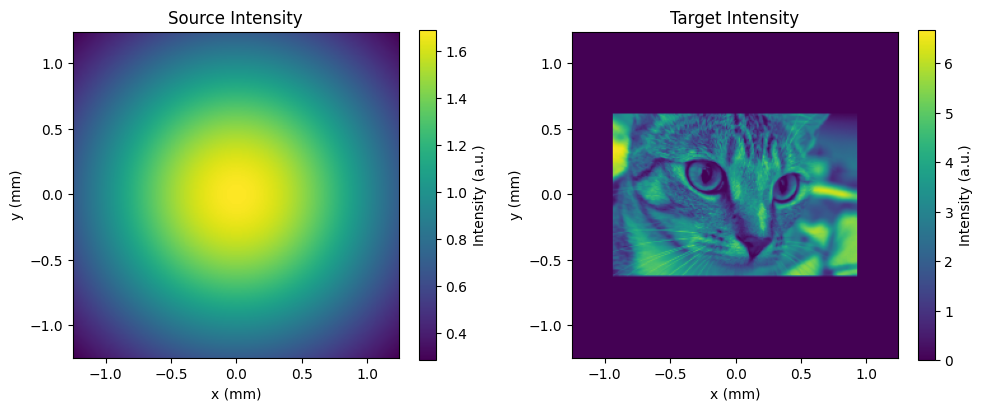

In [5]:
# - No modification necessary -

# Preview the source and target intensity side by side
x_mm = x * 1e3
y_mm = y * 1e3

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Source ---
im0 = axes[0].imshow(
    source_intensity,
    cmap='viridis',
    extent=[x_mm[0], x_mm[-1], y_mm[0], y_mm[-1]],
    origin='lower',
)
axes[0].set_xlabel('x (mm)')
axes[0].set_ylabel('y (mm)')
axes[0].set_title('Source Intensity')
cb0 = fig.colorbar(im0, ax=axes[0])
cb0.set_label('Intensity (a.u.)')

# --- Target ---
im1 = axes[1].imshow(
    target_intensity,
    cmap='viridis',
    extent=[x_mm[0], x_mm[-1], y_mm[0], y_mm[-1]],
    origin='lower',
)
axes[1].set_xlabel('x (mm)')
axes[1].set_ylabel('y (mm)')
axes[1].set_title('Target Intensity')
cb1 = fig.colorbar(im1, ax=axes[1])
cb1.set_label('Intensity (a.u.)')

plt.tight_layout()
plt.show()

## Part 1

In this part you will implement a single pass of the Gerchberg-Saxton algorithm and verify its functionality.

The basic structure that you will implement is as follows:
1. Using the known source intensity, generate an initial guess with random phase
2. Use the following loop to refine the guess until convergence: 
    1. Propagate the field to the target plane
    2. Keep the phase of the field, but assign the amplitude to be that of the target 
    3. Inverse propagate back to the source plane
    4. Keep the phase of the field, but assign the amplitude to be that of the source

In this part you will implement one pass of the loop in the function gs_iteration.

After you have completed the update loop, run the provided visualization code to verify that your code is working.

In [6]:
def gs_iteration(U_source):
    #Perform one Gerchberg-Saxton constraint-projection iteration.

    # Step 1: propagate to focal plane
    U_focal = propagate_to_target_plane(U_source)

    # Step 2: replace amplitude with sqrt(target_intensity), preserve phase
    U_focal_new = np.sqrt(target_intensity) * np.exp(1j * np.angle(U_focal))

    # Step 3: propagate back to source plane
    U_source_new = propagate_to_source_plane(U_focal_new)

    # Step 4: replace amplitude with 1.0, preserve phase
    U_source_out = np.sqrt(source_intensity) * np.exp(1j * np.angle(U_source_new))

    return U_source_out

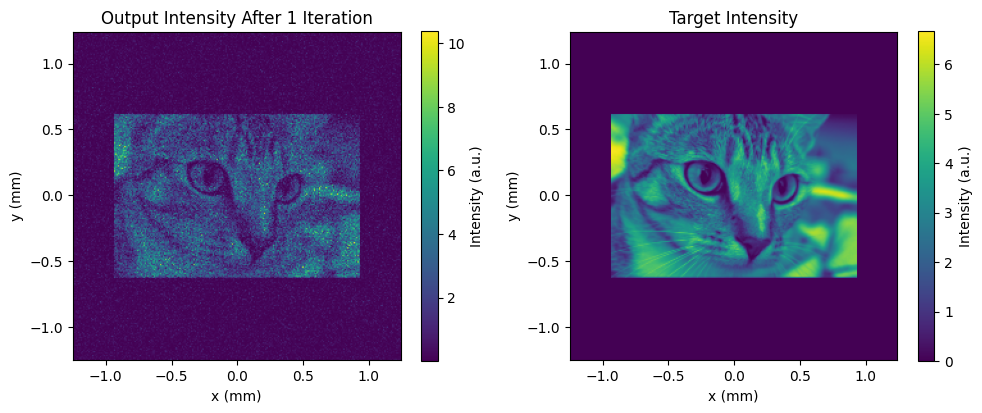

In [7]:
# - No modification necessary -

# Run a single GS iteration from a random start and compare to the target
U_init = np.exp(1j * 2 * np.pi * np.random.rand(N, N)).astype(np.complex128) * np.sqrt(source_intensity)
U_after_one = gs_iteration(U_init)

intensity_after_one = np.abs(propagate_to_target_plane(U_after_one)) ** 2

vmax_check = max(intensity_after_one.max(), target_intensity.max())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(
    intensity_after_one,
    cmap='viridis',
    extent=[x_mm[0], x_mm[-1], y_mm[0], y_mm[-1]],
    origin='lower',
)
axes[0].set_xlabel('x (mm)')
axes[0].set_ylabel('y (mm)')
axes[0].set_title('Output Intensity After 1 Iteration')
fig.colorbar(im0, ax=axes[0]).set_label('Intensity (a.u.)')

im1 = axes[1].imshow(
    target_intensity,
    cmap='viridis',
    extent=[x_mm[0], x_mm[-1], y_mm[0], y_mm[-1]],
    origin='lower',
)
axes[1].set_xlabel('x (mm)')
axes[1].set_ylabel('y (mm)')
axes[1].set_title('Target Intensity')
fig.colorbar(im1, ax=axes[1]).set_label('Intensity (a.u.)')

plt.tight_layout()
plt.show()

## Part 2

Now that you have implemented one pass of the Gerchberg-Saxton algorithm, you will implement the function run_gs to iteratively call your update function and build a proper estimate of the initial source phase.

In order to track how the estimate is improving, you will also record the mean-squared error (MSE) between your guess for the target output and the true target output at each update step.

After you have implemented these, run the provided plotting code to examine your output.

Then, answer the following questions:
1. Normally we define the Gerchberg-Saxton algorithm as using Fourier transforms to go between the source and target plane. Why does our implementation with finite propagation still work?
2. Is there only one "true" phase mask that will generate the target output for us? If so, did we find it (or at least get close)?
3. What does the main remaining source of error appear to be? Can you come up with any arguments for why this may be?

In [8]:
def run_gs(n_iterations):
    """
    Run the full Gerchberg-Saxton iterative loop.

    Executes the GS algorithm for a given number of iterations, tracking
    the mean squared error (MSE) between the reconstructed focal-plane
    intensity and `target_intensity` at each step.

    Algorithm outline:
      1. Validate: raise ValueError if n_iterations < 0.
      2. Initialize the source-plane field with uniform amplitude and
         random phase:
             U = exp(i * 2 * pi * random(N, N))
      3. For each iteration t in range(n_iterations):
             a. U = gs_iteration(U)
             b. Compute MSE:
                    intensity = |propagate_to_target_plane(U)|^2
                    mse = mean((intensity - target_intensity)^2)
             c. Append mse to mse_history.
      4. Return (U, mse_history).
    """
    if n_iterations < 0:
        raise ValueError(
            f"n_iterations must be >= 0, got {n_iterations}."
        )

    # Initialise with uniform amplitude and random phase
    U = np.exp(1j * 2 * np.pi * np.random.rand(N, N)).astype(np.complex128)

    mse_history = []
    for _ in range(n_iterations):
        U = gs_iteration(U)
        intensity = np.abs(propagate_to_target_plane(U)) ** 2
        mse = float(np.mean((intensity - target_intensity) ** 2))
        mse_history.append(mse)

    return U, mse_history


U_final, mse_history = run_gs(250)

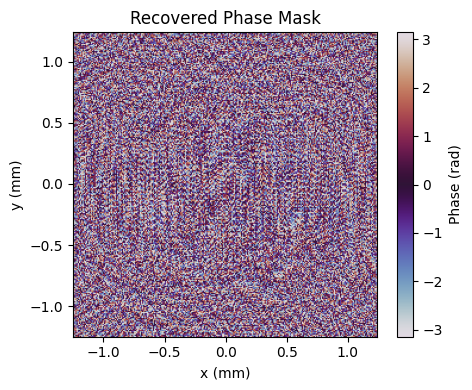

In [9]:
# - No modification necessary -

x_mm = x * 1e3
y_mm = y * 1e3

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(
    np.angle(U_final),
    cmap='twilight',
    extent=[x_mm[0], x_mm[-1], y_mm[0], y_mm[-1]],
    origin='lower',
)
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('Recovered Phase Mask')
cb = fig.colorbar(im, ax=ax)
cb.set_label('Phase (rad)')
plt.tight_layout()
plt.show()

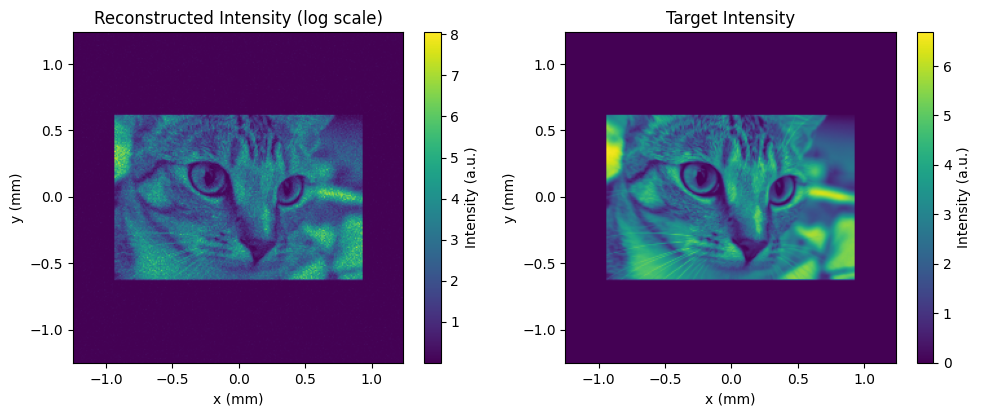

In [10]:
# - No modification necessary -

reconstructed_intensity = np.abs(propagate_to_target_plane(U_final)) ** 2


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(
    reconstructed_intensity,
    cmap='viridis',
    extent=[x_mm[0], x_mm[-1], y_mm[0], y_mm[-1]],
    origin='lower',
)
axes[0].set_xlabel('x (mm)')
axes[0].set_ylabel('y (mm)')
axes[0].set_title('Reconstructed Intensity')
cb0 = fig.colorbar(im0, ax=axes[0])
cb0.set_label('Intensity (a.u.)')

im1 = axes[1].imshow(
    target_intensity,
    cmap='viridis',
    extent=[x_mm[0], x_mm[-1], y_mm[0], y_mm[-1]],
    origin='lower',
)
axes[1].set_xlabel('x (mm)')
axes[1].set_ylabel('y (mm)')
axes[1].set_title('Target Intensity')
cb1 = fig.colorbar(im1, ax=axes[1])
cb1.set_label('Intensity (a.u.)')

plt.tight_layout()
plt.show()

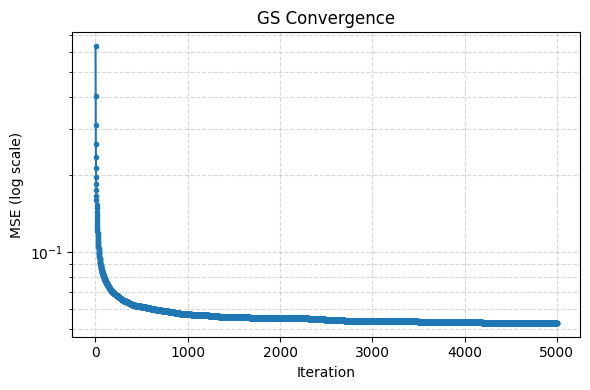

In [11]:
# - No modification necessary -

if len(mse_history) == 0:
    print("No convergence data to plot: mse_history is empty (run_gs was called with 0 iterations).")
else:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(range(1, len(mse_history) + 1), mse_history, marker='o', markersize=3, linewidth=1.5)
    ax.set_yscale('log')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('MSE (log scale)')
    ax.set_title('GS Convergence')
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

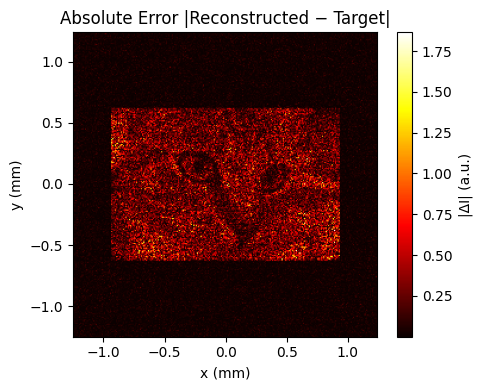

In [12]:
# - No modification necessary -

# Pixel-wise absolute error between reconstructed and target intensity
error_image = np.abs(reconstructed_intensity - target_intensity)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(
    error_image,
    cmap='hot',
    extent=[x_mm[0], x_mm[-1], y_mm[0], y_mm[-1]],
    origin='lower',
)
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('Absolute Error |Reconstructed − Target|')
cb = fig.colorbar(im, ax=ax)
cb.set_label('|ΔI| (a.u.)')
plt.tight_layout()
plt.show()

## Discussion

1) The Gerchberg-Saxton algorithm works on the principle that by fixing the source and output intensities to be as measured, the phase must progressively walk to be closer and closer to the true phase of the field. This assertion is itself agnostic to whether the light is propagated just a short distance or all the way to the far field, as the fundamental dynamics are unchanged.

2) No, there is not one single correct phase mask. We do not know, nor need to know the phase of the output field, so there are infinitely many possible phase distributions that would produce a valid result at the target, and therefore infinitely many possible input fields. The algorithm takes us towards one local minimum, but it does not guarantee a global minimum, so we cannot say that we necessarily got the best possible mask, much less a one "true" mask.

3) The actual pattern seems to have been well captured, but the amplitude scaling still seems to be a bit off. We can see from the single round of Gerchberg-Saxton that the algorithm actually had a fairly easy time capturing the general details of the cat, but it got the amplitude completely wrong. This implies that it is much more difficult for the phase mask to properly distribute the beam and convert the gaussian into a rectangle than it is for the cat features to be induced. We know from the implementation that the total intensity in both the source and target is the same, so we can state that it must really be this reshaping that is difficult, and there are not other complicating factors such as needing to remove light from the simulation or not having enough in the first place.

# Bonus

Take a look at the original paper where Gerchberg and Saxton propose this methodology. One thing you will have noted from your simulation is that the MSE between your output and the target seems to have monotonically decreased as iterations were run. In your own words, describe how Gerchberg and Saxton proved that this must be the case.


## Discussion
On the source plane, we can think as each point in our image as being some complex vector. Casting the amplitude to that of the source is the same as adding a counterpropagating vector to each point. The sum of the energies of these counterpropagating vectors is the error of our field.

Because we are using a linear transform, we can think of the transformed output of propagating to the target plane as the sum of the transformed initial vectors and the transformed error vectors. The magnitude of the transform of the initial vectors must match the target amplitude (since that is what they were retrieved from), so the magnitude of the new error vector between the resulting prediction (the sum of the two transformed vectors) and the target amplitude must be less than or equal to the magnitude of the transformed initial error vector.

Since the magnitude of the new error vector must be less than or equal to the magnitude of the transformed old error vector at each point, and by Parseval's theorem we know that the total energy of the old error vectors must have been preserved through the transformation, we can say that the overall error across the whole image must have decreased or stayed the same.

The same logic holds for switching between the target and the source plane, so we know that a complete loop of the Gerchberg-saxton algorithm cannot increase error.